In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Helper for the map plots

In [2]:
def plot_map(data, title, cbar_label, cmap="YlOrRd", vmin=None, vmax=None):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    p = ax.pcolormesh(data.lon, data.lat, data,
                      cmap=cmap, vmin=vmin, vmax=vmax, shading="auto",
                      transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.7, label=cbar_label)
    ax.set_title(title)
    plt.show()

## Helper for the time series plots 

In [3]:
def plot_timeseries(ts, title, ylabel, color):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts.time, ts, color=color, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. Read the detrended CO field

In [4]:
ds = xr.open_dataset("detr_field.nc")
ds

<xarray.Dataset> Size: 5MB
Dimensions:                        (time: 276, lat: 36, lon: 61)
Coordinates:
  * time                           (time) datetime64[ns] 2kB 2003-01-01 ... 2...
  * lat                            (lat) float32 144B 14.5 15.5 ... 48.5 49.5
  * lon                            (lon) float32 244B -126.5 -125.5 ... -66.5
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float64 5MB ...

In [5]:
ds

<xarray.Dataset> Size: 5MB
Dimensions:                        (time: 276, lat: 36, lon: 61)
Coordinates:
  * time                           (time) datetime64[ns] 2kB 2003-01-01 ... 2...
  * lat                            (lat) float32 144B 14.5 15.5 ... 48.5 49.5
  * lon                            (lon) float32 244B -126.5 -125.5 ... -66.5
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float64 5MB ...

In [6]:
detr = ds["__xarray_dataarray_variable__"]
detr = detr.rename("co_detrended")
print(detr)

<xarray.DataArray 'co_detrended' (time: 276, lat: 36, lon: 61)> Size: 5MB
[606096 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-12-01
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5


In [7]:
print("time range :", str(detr.time.values[0])[:10], "to", str(detr.time.values[-1])[:10])
print("lat range  :", float(detr.lat.min()), "to", float(detr.lat.max()))
print("lon range  :", float(detr.lon.min()), "to", float(detr.lon.max()))
print("min / max  :", float(detr.min()), "/", float(detr.max()))
print("mean       :", float(detr.mean()))

time range : 2003-01-01 to 2025-12-01
lat range  : 14.5 to 49.5
lon range  : -126.5 to -66.5
min / max  : -2.9682074772681273e-08 / 6.809788681909778e-08
mean       : 3.344009899590049e-25


## 2. Standard deviation map

In [8]:
std_map = detr.std(dim="time")
print(std_map)

<xarray.DataArray 'co_detrended' (lat: 36, lon: 61)> Size: 18kB
array([[5.03576302e-09, 5.00326611e-09, 4.86422646e-09, ...,
        5.69293924e-09, 5.66749946e-09, 5.66315572e-09],
       [5.52723621e-09, 5.45521719e-09, 5.30752368e-09, ...,
        5.65762648e-09, 5.64863121e-09, 5.68083279e-09],
       [6.06297767e-09, 5.90121233e-09, 5.73925233e-09, ...,
        5.64731260e-09, 5.72073235e-09, 5.71989160e-09],
       ...,
       [9.83520267e-09, 9.95676928e-09, 9.89209386e-09, ...,
        8.58150446e-09, 8.43362781e-09, 8.26910555e-09],
       [1.00584093e-08, 1.01029973e-08, 9.81385184e-09, ...,
        8.29552534e-09, 8.46465118e-09, 8.51263817e-09],
       [9.84082128e-09, 9.68802615e-09, 1.00977105e-08, ...,
        8.69528713e-09, 8.28236122e-09, 7.93003835e-09]], shape=(36, 61))
Coordinates:
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5


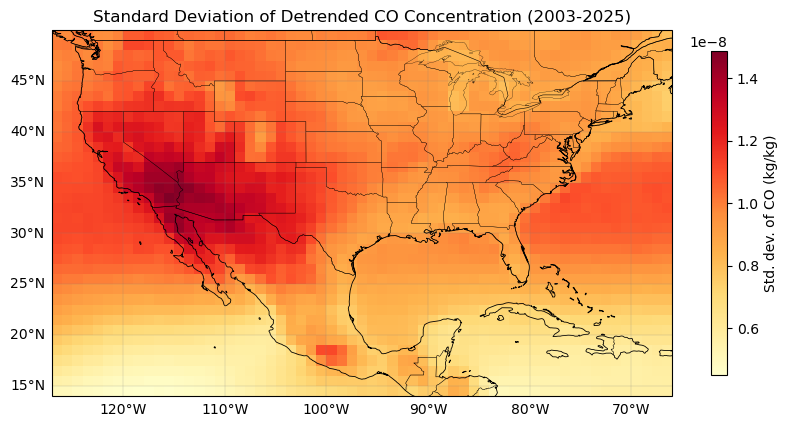

In [9]:
plot_map(std_map,
         "Standard Deviation of Detrended CO Concentration (2003-2025)",
         "Std. dev. of CO (kg/kg)")

## 2b. Standard deviation of the periodicities

In [10]:
ds_per = xr.open_dataset("periodicities.nc")
per = ds_per["periodicities"]
per_std_map = per.std(dim="time")
print(per_std_map)

<xarray.DataArray 'periodicities' (lat: 36, lon: 61)> Size: 18kB
array([[3.69969418e-09, 3.60774477e-09, 3.47051221e-09, ...,
        4.55537329e-09, 4.53823811e-09, 4.56240817e-09],
       [4.17166402e-09, 4.04230557e-09, 3.89604624e-09, ...,
        4.56572200e-09, 4.54533338e-09, 4.57610816e-09],
       [4.65637743e-09, 4.50380841e-09, 4.32799899e-09, ...,
        4.56814758e-09, 4.64794195e-09, 4.63999035e-09],
       ...,
       [8.34284849e-09, 8.56084379e-09, 8.56728160e-09, ...,
        6.51503549e-09, 6.45519582e-09, 6.17077964e-09],
       [8.55079361e-09, 8.67402910e-09, 8.42010600e-09, ...,
        5.98605501e-09, 6.27463497e-09, 6.32265351e-09],
       [8.30025920e-09, 8.06435783e-09, 8.44550044e-09, ...,
        6.22103478e-09, 5.80091151e-09, 5.41316715e-09]], shape=(36, 61))
Coordinates:
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5
Attributes:
    long_name:   

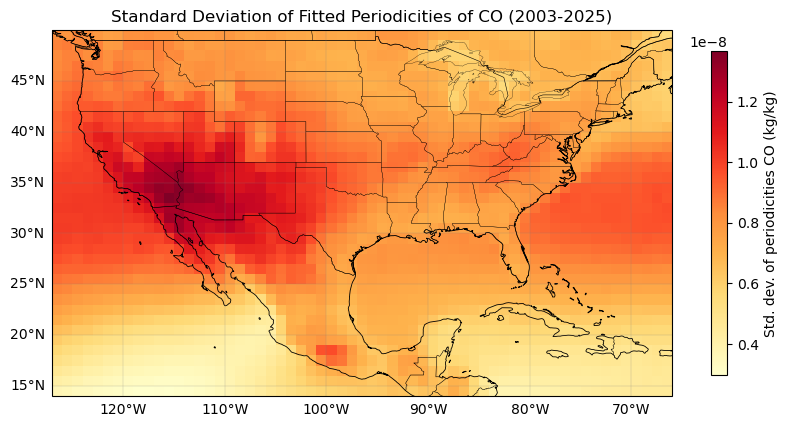

In [11]:
plot_map(per_std_map,
         "Standard Deviation of Fitted Periodicities of CO (2003-2025)",
         "Std. dev. of periodicities CO (kg/kg)")

## 2c. Mean map of the periodicities

In [12]:
per_mean_map = per.mean(dim="time")
print(per_mean_map)

<xarray.DataArray 'periodicities' (lat: 36, lon: 61)> Size: 18kB
array([[ 4.31572494e-25,  4.59295032e-25,  4.96757922e-25, ...,
         1.02198764e-24,  9.98011391e-25,  9.83775493e-25],
       [ 2.72729840e-25,  4.15088822e-25,  3.79124447e-25, ...,
         1.15985108e-24,  1.07743272e-24,  9.90518813e-25],
       [ 3.16936050e-25,  3.17685308e-25,  3.43909331e-25, ...,
         1.13362705e-24,  1.12538522e-24,  1.10702840e-24],
       ...,
       [-1.03097873e-24, -1.06244756e-24, -5.28976008e-25, ...,
         1.37863435e-24,  1.30670561e-24,  1.20480654e-24],
       [-8.94613815e-25, -8.10696941e-25, -4.40563587e-25, ...,
         9.95014360e-25,  1.09691342e-24,  1.16884217e-24],
       [-2.48753590e-25,  1.01899061e-25,  4.22581400e-25, ...,
         1.22278873e-24,  8.27180613e-25,  4.79524993e-25]],
      shape=(36, 61))
Coordinates:
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5

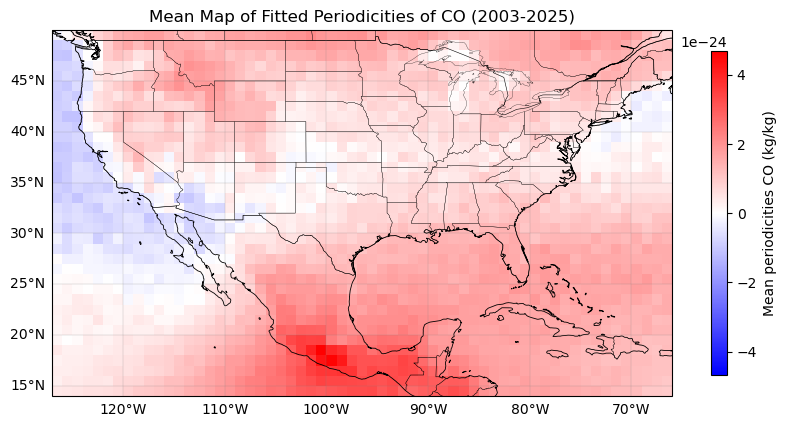

In [13]:
vmax = float(abs(per_mean_map).max())
plot_map(per_mean_map,
         "Mean Map of Fitted Periodicities of CO (2003-2025)",
         "Mean periodicities CO (kg/kg)",
         cmap="bwr", vmin=-vmax, vmax=vmax)

## 3. Residuals = detrended field - periodicities

In [14]:
ds_per

<xarray.Dataset> Size: 24MB
Dimensions:        (time: 276, lat: 36, lon: 61)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2003-01-01 ... 2025-12-01
  * lat            (lat) float32 144B 14.5 15.5 16.5 17.5 ... 47.5 48.5 49.5
  * lon            (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5
Data variables:
    periodicities  (time, lat, lon) float64 5MB 3.143e-09 ... -5.562e-09
    harmonic_12m   (time, lat, lon) float64 5MB ...
    harmonic_6m    (time, lat, lon) float64 5MB ...
    harmonic_4m    (time, lat, lon) float64 5MB ...
    residual       (time, lat, lon) float64 5MB ...
Attributes:
    title:                             AIRS CO mid-troposphere — combined har...
    source:                            detr_field.nc, least-squares harmonic ...
    time_coverage:                     2003-01-01 to 2025-12-01
    variance_explained_total_percent:  71.25694936138918
    variance_explained_12m_percent:    57.47187840344678
    variance_explained_6m_percent:     10.634866503919614
    variance_explained_4m_percent:     3.1502044540227914

In [15]:
residual = detr - per
print(residual)

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
array([[[ 4.16653091e-09,  4.06449921e-09,  4.20883172e-09, ...,
          2.24376435e-09,  2.63445981e-09,  2.74368223e-09],
        [ 4.38849095e-09,  4.20535569e-09,  4.49409054e-09, ...,
          1.71978867e-09,  1.98823867e-09,  2.57041475e-09],
        [ 4.92811876e-09,  4.70042331e-09,  4.77470707e-09, ...,
          1.40166698e-09,  1.84719647e-09,  2.13422935e-09],
        ...,
        [ 3.15655886e-10,  2.77669223e-10,  2.01620461e-09, ...,
          1.36888170e-09,  1.12151008e-09,  1.72334392e-09],
        [-4.75429927e-10, -1.65860399e-10, -1.31539447e-10, ...,
          2.18661394e-09,  2.13784068e-09,  2.50960189e-09],
        [ 2.13374803e-11, -5.50106822e-10, -9.46303511e-11, ...,
          2.43796894e-09,  4.93386386e-09,  6.55437641e-09]],

       [[ 5.08531791e-10,  9.97346267e-10,  6.73820176e-10, ...,
         -2.27755811e-10, -4.46530556e-10, -5.60002500e-10],
        [ 1.01285088e-09,  4.77080112e-10,  

In [16]:
res_mean_map = residual.mean(dim="time")
vmax = float(abs(res_mean_map).max())
print("colorbar limits: -", vmax, "to +", vmax)

colorbar limits: - 1.9519664237528513e-23 to + 1.9519664237528513e-23


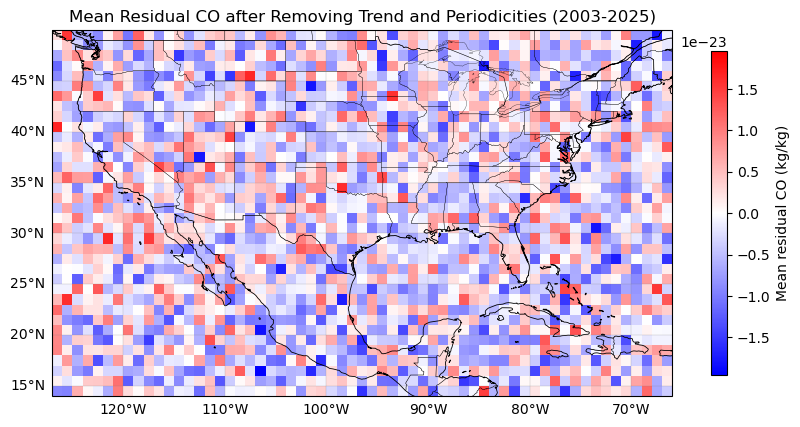

In [17]:
plot_map(res_mean_map,
         "Mean Residual CO after Removing Trend and Periodicities (2003-2025)",
         "Mean residual CO (kg/kg)",
         cmap="bwr", vmin=-vmax, vmax=vmax)

The mean residual map above is essentially zero everywhere (~1e-23, i.e. floating point noise).
That is expected: the harmonics are fitted per pixel by least squares, so the residual has
zero time mean at every grid point by construction. The standard deviation of the residual
below is the informative map - it shows where the harmonic fit leaves the most unexplained
variability.

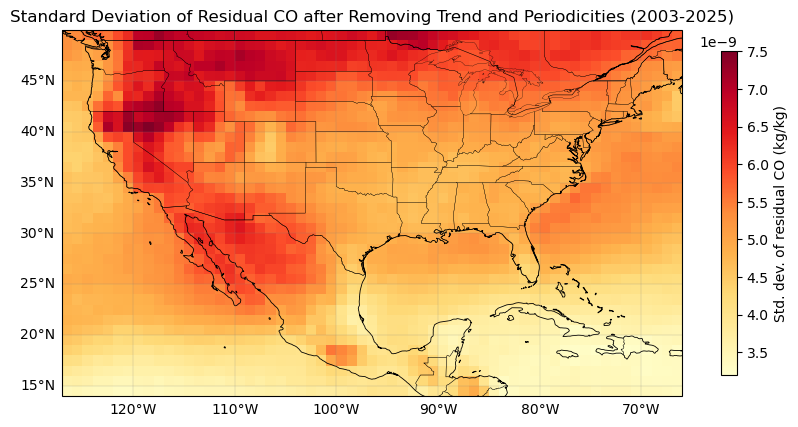

In [18]:
res_std_map = residual.std(dim="time")
plot_map(res_std_map,
         "Standard Deviation of Residual CO after Removing Trend and Periodicities (2003-2025)",
         "Std. dev. of residual CO (kg/kg)")

## 4. Domain mean time series of the detrended field

In [19]:
ts_detr = detr.mean(dim=["lat", "lon"])
print(ts_detr)

<xarray.DataArray 'co_detrended' (time: 276)> Size: 2kB
array([ 2.41239223e-09,  3.48337390e-09,  1.01491299e-08,  1.95067313e-08,
        1.53934897e-08,  7.92983777e-09, -5.05062585e-09, -8.80833367e-09,
       -7.10674821e-09, -7.06031044e-09, -5.29392647e-09, -3.66348301e-09,
        5.27109109e-10,  5.98713134e-09,  1.17642311e-08,  2.27144797e-08,
        7.64542496e-09, -4.64950791e-09, -7.97142717e-09, -1.13936781e-08,
       -1.20221095e-08, -1.17179925e-08, -6.56198279e-09, -3.94634268e-09,
        1.40423011e-09,  9.91177673e-09,  2.00867612e-08,  2.16677057e-08,
        1.57355379e-08, -1.35947606e-09, -8.73120755e-09, -1.12551723e-08,
       -1.21474276e-08, -8.17923292e-09, -5.03288911e-09, -6.65765466e-10,
        2.72564733e-09,  1.27465222e-09,  8.25641658e-09,  1.31705846e-08,
        9.08298543e-09, -2.17820341e-10, -6.83205552e-09, -1.03552160e-08,
       -9.42455347e-09, -8.55635254e-09, -3.07944879e-09, -1.36496366e-10,
        1.81565009e-09,  8.46366066e-09,  1.

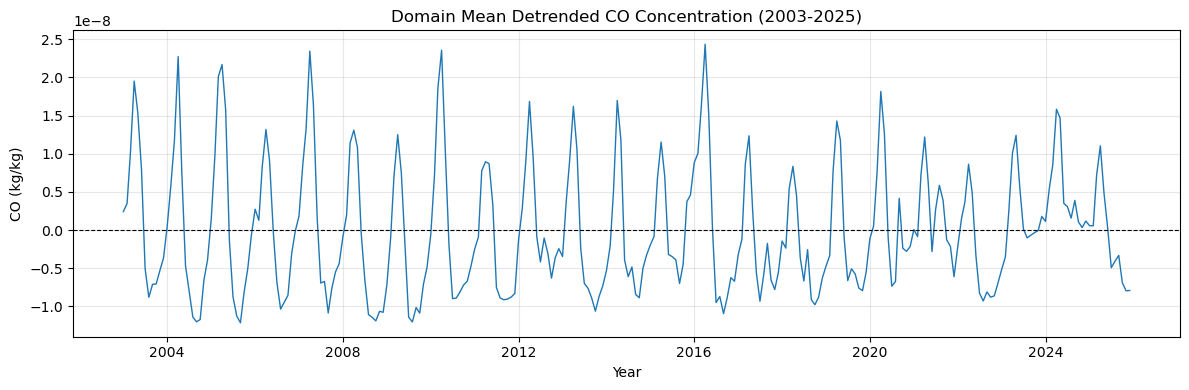

In [20]:
plot_timeseries(ts_detr,
                "Domain Mean Detrended CO Concentration (2003-2025)",
                "CO (kg/kg)",
                "tab:blue")

## 5. Domain mean time series of the periodicities

In [21]:
ts_per = per.mean(dim=["lat", "lon"])
print(ts_per)

<xarray.DataArray 'periodicities' (time: 276)> Size: 2kB
array([-1.55298078e-09,  2.03284940e-09,  9.75888428e-09,  1.49432195e-08,
        1.01054653e-08, -3.78502555e-10, -6.27510139e-09, -6.21866869e-09,
       -6.11662141e-09, -7.11513734e-09, -5.91964604e-09, -3.26376032e-09,
       -1.55298078e-09,  2.03284940e-09,  9.75888428e-09,  1.49432195e-08,
        1.01054653e-08, -3.78502555e-10, -6.27510139e-09, -6.21866869e-09,
       -6.11662141e-09, -7.11513734e-09, -5.91964604e-09, -3.26376032e-09,
       -1.55298078e-09,  2.03284940e-09,  9.75888428e-09,  1.49432195e-08,
        1.01054653e-08, -3.78502555e-10, -6.27510139e-09, -6.21866869e-09,
       -6.11662141e-09, -7.11513734e-09, -5.91964604e-09, -3.26376032e-09,
       -1.55298078e-09,  2.03284940e-09,  9.75888428e-09,  1.49432195e-08,
        1.01054653e-08, -3.78502555e-10, -6.27510139e-09, -6.21866869e-09,
       -6.11662141e-09, -7.11513734e-09, -5.91964604e-09, -3.26376032e-09,
       -1.55298078e-09,  2.03284940e-09,  9

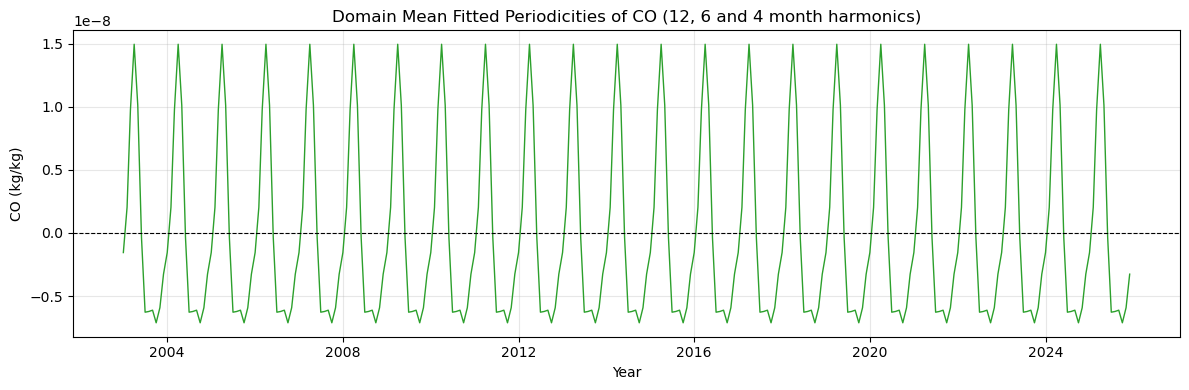

In [22]:
plot_timeseries(ts_per,
                "Domain Mean Fitted Periodicities of CO (12, 6 and 4 month harmonics)",
                "CO (kg/kg)",
                "tab:green")

## 6. Mean anomaly time series = (4) - (5)

In [23]:
ts_anom = ts_detr - ts_per
print(ts_anom)

<xarray.DataArray (time: 276)> Size: 2kB
array([ 3.96537301e-09,  1.45052450e-09,  3.90245582e-10,  4.56351183e-09,
        5.28802440e-09,  8.30834033e-09,  1.22447554e-09, -2.58966498e-09,
       -9.90126806e-10,  5.48268983e-11,  6.25719570e-10, -3.99722695e-10,
        2.08008989e-09,  3.95428194e-09,  2.00534685e-09,  7.77126020e-09,
       -2.46004037e-09, -4.27100535e-09, -1.69632578e-09, -5.17500937e-09,
       -5.90548808e-09, -4.60285517e-09, -6.42336749e-10, -6.82582362e-10,
        2.95721089e-09,  7.87892733e-09,  1.03278769e-08,  6.72448621e-09,
        5.63007260e-09, -9.80973507e-10, -2.45610616e-09, -5.03650363e-09,
       -6.03080616e-09, -1.06409558e-09,  8.86756923e-10,  2.59799485e-09,
        4.27862811e-09, -7.58197184e-10, -1.50246770e-09, -1.77263488e-09,
       -1.02247991e-09,  1.60682214e-10, -5.56954135e-10, -4.13654735e-09,
       -3.30793206e-09, -1.44121521e-09,  2.84019725e-09,  3.12726395e-09,
        3.36863086e-09,  6.43081126e-09,  3.49616483e-09,  

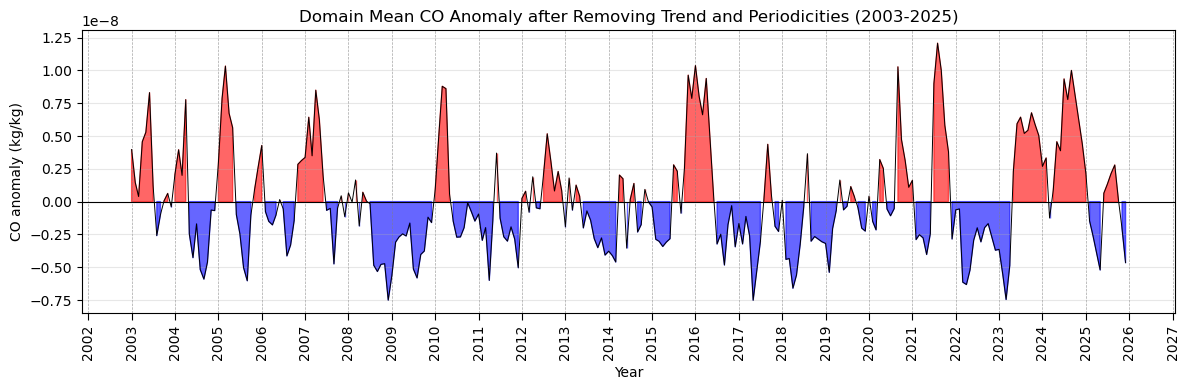

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(ts_anom.time, ts_anom, 0, where=(ts_anom >= 0), color="red", alpha=0.6)
ax.fill_between(ts_anom.time, ts_anom, 0, where=(ts_anom < 0), color="blue", alpha=0.6)
ax.plot(ts_anom.time, ts_anom, color="black", linewidth=0.7)
ax.axhline(0, color="black", linewidth=0.8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", which="major", length=5, rotation=90)
ax.grid(axis="x", which="major", color="gray", linestyle="--", linewidth=0.5, alpha=0.7)
ax.grid(axis="y", linestyle="-", alpha=0.3)

ax.set_title("Domain Mean CO Anomaly after Removing Trend and Periodicities (2003-2025)")
ax.set_xlabel("Year")
ax.set_ylabel("CO anomaly (kg/kg)")
plt.tight_layout()
plt.show()

## 7. Long-term seasonal mean cycle

In [25]:
seasonal_mean_cycle = detr.groupby("time.month").mean(dim="time").rename("co_seasonal_mean_cycle")
print(seasonal_mean_cycle)

<xarray.DataArray 'co_seasonal_mean_cycle' (month: 12, lat: 36, lon: 61)> Size: 211kB
array([[[ 3.79328905e-09,  3.58714466e-09,  3.35615301e-09, ...,
         -1.39950086e-10, -1.27120297e-10, -1.15761226e-10],
        [ 4.00127061e-09,  3.90475998e-09,  3.56020408e-09, ...,
          1.51807914e-10,  1.41065202e-10,  1.22592882e-10],
        [ 4.30242354e-09,  4.15743771e-09,  3.73068423e-09, ...,
          3.90357443e-10,  3.49709160e-10,  3.14502285e-10],
        ...,
        [ 1.27023179e-09,  1.28997952e-09,  6.76945347e-10, ...,
         -6.72744879e-09, -6.29887206e-09, -5.69984407e-09],
        [ 9.36286957e-10,  6.03920710e-10, -6.77944567e-10, ...,
         -5.88732065e-09, -6.48807664e-09, -6.35493325e-09],
        [-2.18534128e-10, -1.56490076e-09, -1.93817873e-09, ...,
         -7.18980052e-09, -6.03195532e-09, -4.48102134e-09]],

       [[ 2.37354704e-09,  2.19375129e-09,  2.10314274e-09, ...,
          5.30695314e-10,  4.69879244e-10,  4.11008413e-10],
        [ 2.63337

In [26]:
seasonal_mean_cycle.to_dataset().to_netcdf("seasonal_mean_cycle.nc")

## 8. Standard deviation of the seasonal mean cycle

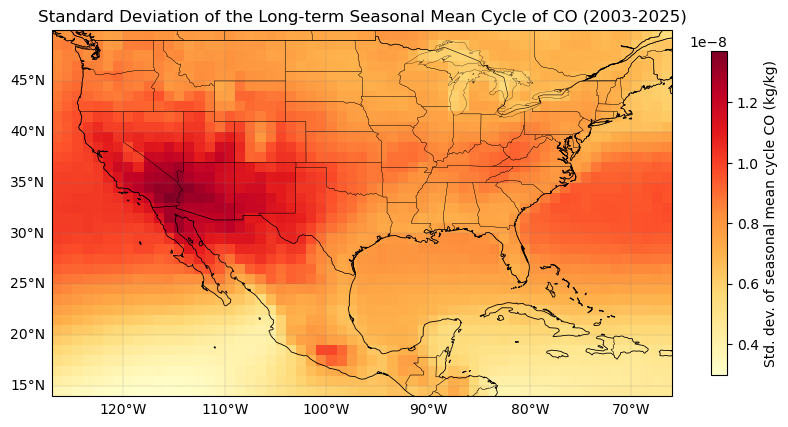

In [27]:
seasonal_std_map = seasonal_mean_cycle.std(dim="month")
plot_map(seasonal_std_map,
         "Standard Deviation of the Long-term Seasonal Mean Cycle of CO (2003-2025)",
         "Std. dev. of seasonal mean cycle CO (kg/kg)")

## 8b. Mean map of the seasonal mean cycle

In [28]:
seasonal_mean_map = seasonal_mean_cycle.mean(dim="month")
print(seasonal_mean_map)

<xarray.DataArray 'co_seasonal_mean_cycle' (lat: 36, lon: 61)> Size: 18kB
array([[-8.53030007e-24, -9.47811119e-24,  6.65191076e-24, ...,
         1.25628056e-23, -6.16938874e-24, -2.74003578e-24],
       [ 1.45618254e-24, -1.87838931e-24,  1.20630506e-25, ...,
         9.75383806e-24, -5.42837277e-24,  2.70556992e-24],
       [-3.17947548e-24,  2.92098154e-24, -7.32399501e-24, ...,
        -6.61744490e-24,  3.10192730e-24,  3.03299558e-24],
       ...,
       [-6.16938874e-24,  2.51600770e-24,  8.47860128e-24, ...,
        -1.79222466e-24,  1.24077092e-24, -7.58248895e-24],
       [-9.30578189e-25,  4.41162993e-24, -3.30872245e-24, ...,
        -2.06795153e-24,  2.61940527e-24, -5.51453742e-25],
       [ 2.82620043e-24,  1.43377973e-23, -5.65240085e-24, ...,
        -6.47958146e-24, -1.70950660e-23, -6.89317177e-26]],
      shape=(36, 61))
Coordinates:
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 

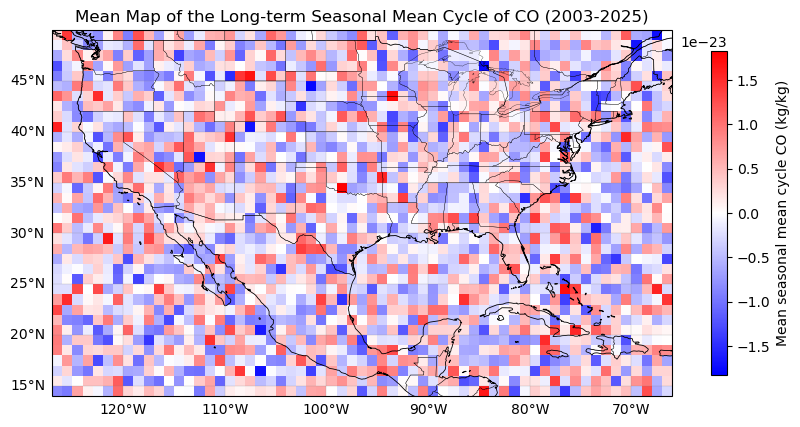

In [29]:
vmax = float(abs(seasonal_mean_map).max())
plot_map(seasonal_mean_map,
         "Mean Map of the Long-term Seasonal Mean Cycle of CO (2003-2025)",
         "Mean seasonal mean cycle CO (kg/kg)",
         cmap="bwr", vmin=-vmax, vmax=vmax)

## 9. Domain mean seasonal mean cycle

In [30]:
ts_seasonal = seasonal_mean_cycle.mean(dim=["lat", "lon"])
print(ts_seasonal)

<xarray.DataArray 'co_seasonal_mean_cycle' (month: 12)> Size: 96B
array([-9.39855578e-10,  2.03392981e-09,  9.25451680e-09,  1.54471288e-08,
        1.00234408e-08, -6.86578686e-10, -5.97120726e-09, -6.20741455e-09,
       -6.32937924e-09, -7.12648447e-09, -5.40082983e-09, -4.09726664e-09])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12


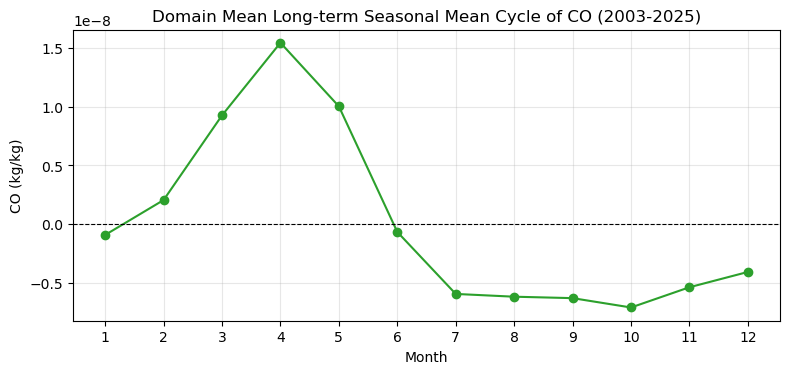

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts_seasonal.month, ts_seasonal, marker="o", color="tab:green")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(1, 13))
ax.set_title("Domain Mean Long-term Seasonal Mean Cycle of CO (2003-2025)")
ax.set_xlabel("Month")
ax.set_ylabel("CO (kg/kg)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Anomalies after removing the seasonal mean cycle

In [32]:
seasonal_anomaly = detr.groupby("time.month") - seasonal_mean_cycle
print(seasonal_anomaly)

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
array([[[ 3.51603077e-09,  3.45776569e-09,  3.62340093e-09, ...,
          1.85687690e-09,  2.20135920e-09,  2.31519593e-09],
        [ 3.66023046e-09,  3.47562431e-09,  3.79271203e-09, ...,
          1.36841859e-09,  1.61610882e-09,  2.14544052e-09],
        [ 4.06073285e-09,  3.85322189e-09,  4.11728518e-09, ...,
          9.74216708e-10,  1.44731778e-09,  1.72081231e-09],
        ...,
        [ 4.52475527e-10,  5.79772871e-10,  1.94314550e-09, ...,
          1.46539969e-09,  1.06298660e-09,  1.78095149e-09],
        [-2.01251840e-10,  1.37665251e-10,  1.00446494e-10, ...,
          2.35563513e-09,  2.21986663e-09,  2.59363572e-09],
        [ 1.03670193e-10, -4.04273941e-10, -1.59121272e-11, ...,
          2.53758947e-09,  5.14920726e-09,  6.76162558e-09]],

       [[ 9.44439447e-10,  1.45726444e-09,  1.12028245e-09, ...,
         -1.11657340e-10, -2.17111098e-10, -3.46017387e-10],
        [ 1.52248448e-09,  1.01076732e-09,  

In [33]:
seasonal_anomaly.drop_vars("month").rename("co_anomaly").to_dataset().to_netcdf("anomalies.nc")

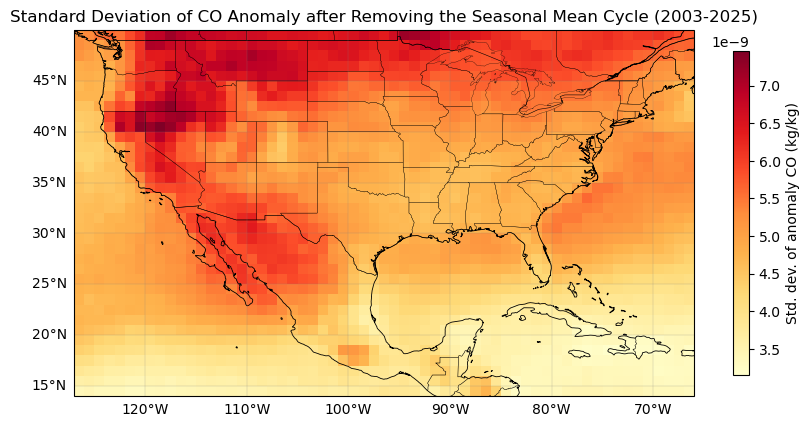

In [34]:
seasonal_anomaly_std_map = seasonal_anomaly.std(dim="time")
plot_map(seasonal_anomaly_std_map,
         "Standard Deviation of CO Anomaly after Removing the Seasonal Mean Cycle (2003-2025)",
         "Std. dev. of anomaly CO (kg/kg)")

## 10b. Latitude-Time plot of the anomaly

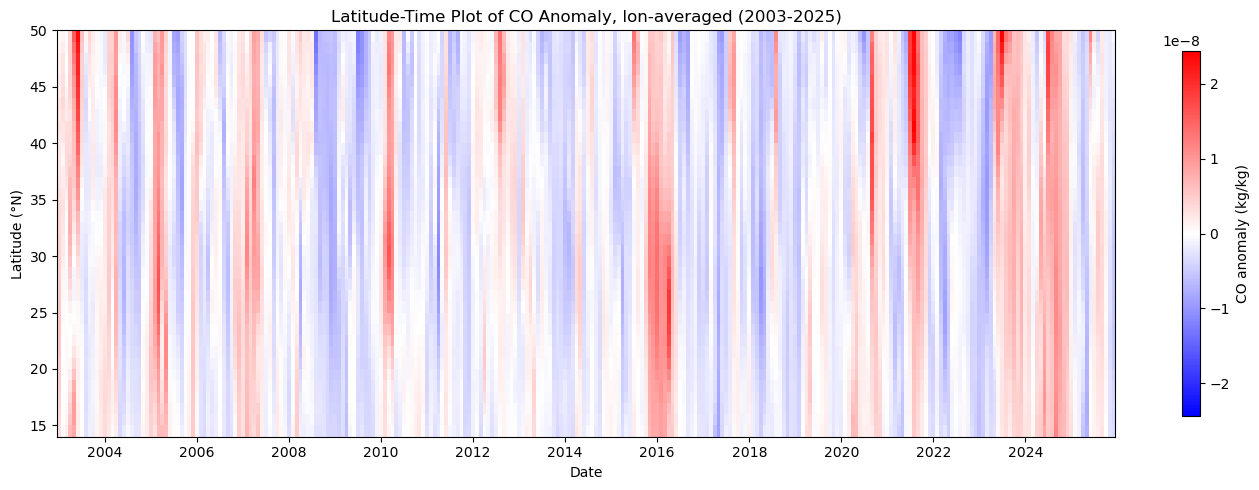

In [35]:
lat_time = seasonal_anomaly.mean(dim="lon")
vmax = float(abs(lat_time).max())

fig, ax = plt.subplots(figsize=(14, 5))
p = ax.pcolormesh(lat_time.time, lat_time.lat, lat_time.T,
                   cmap="bwr", vmin=-vmax, vmax=vmax, shading="auto")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Latitude-Time Plot of CO Anomaly, lon-averaged (2003-2025)")
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.9, label="CO anomaly (kg/kg)")
plt.tight_layout()
plt.show()

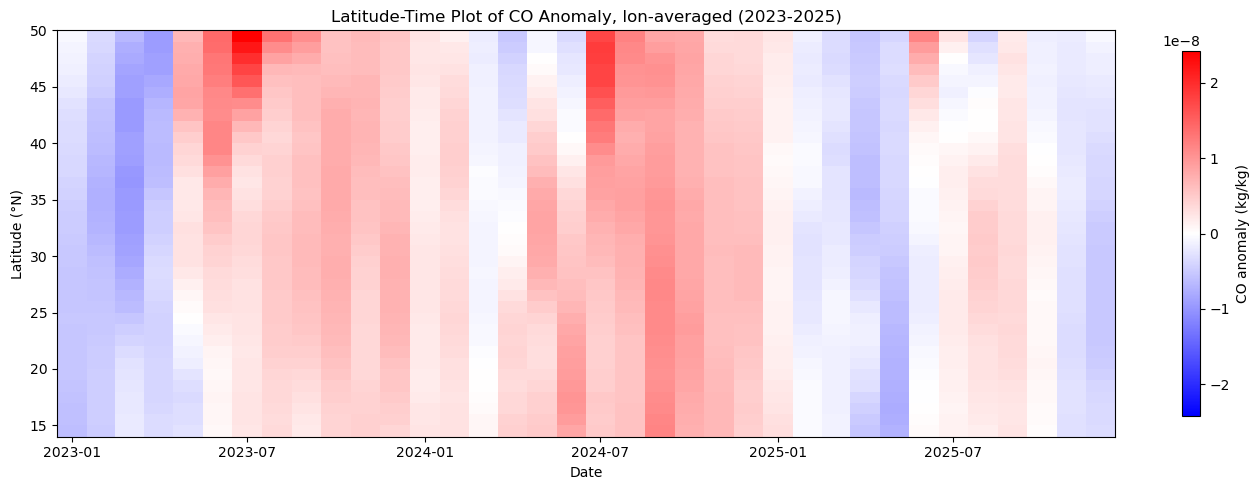

In [36]:
lat_time_recent = lat_time.sel(time=slice("2023-01-01", None))
vmax = float(abs(lat_time_recent).max())

fig, ax = plt.subplots(figsize=(14, 5))
p = ax.pcolormesh(lat_time_recent.time, lat_time_recent.lat, lat_time_recent.T,
                   cmap="bwr", vmin=-vmax, vmax=vmax, shading="auto")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Latitude-Time Plot of CO Anomaly, lon-averaged (2023-2025)")
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.9, label="CO anomaly (kg/kg)")
plt.tight_layout()
plt.show()

## 10c. Longitude-Time plot of the anomaly

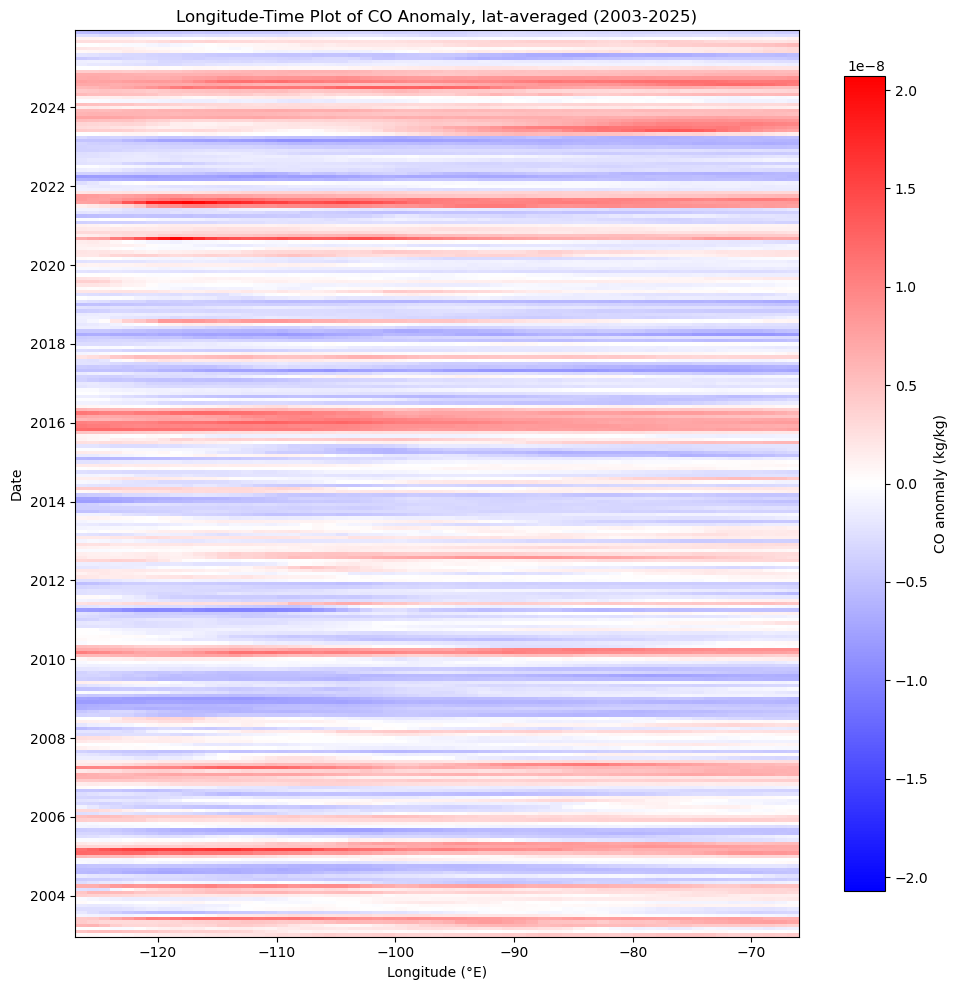

In [37]:
lon_time = seasonal_anomaly.mean(dim="lat")
vmax = float(abs(lon_time).max())

fig, ax = plt.subplots(figsize=(10, 10))
p = ax.pcolormesh(lon_time.lon, lon_time.time, lon_time,
                   cmap="bwr", vmin=-vmax, vmax=vmax, shading="auto")
ax.yaxis.set_major_locator(mdates.YearLocator(2))
ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Date")
ax.set_title("Longitude-Time Plot of CO Anomaly, lat-averaged (2003-2025)")
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.9, label="CO anomaly (kg/kg)")
plt.tight_layout()
plt.show()

## 11. Comparing the periodicities mean map and the seasonal mean cycle mean map

In [38]:
diff_map = per_mean_map - seasonal_mean_map

bias = float(diff_map.mean())
rmse = float((diff_map ** 2).mean() ** 0.5)
max_abs_diff = float(abs(diff_map).max())
corr = float(xr.corr(per_mean_map, seasonal_mean_map))

print("bias (per - seasonal) :", bias)
print("RMSE                  :", rmse)
print("max abs difference    :", max_abs_diff)
print("spatial correlation   :", corr)

bias (per - seasonal) : 1.1703857515233121e-24
RMSE                  : 6.542314948018799e-24
max abs difference    : 1.94372458793937e-23
spatial correlation   : 0.008132512561458928


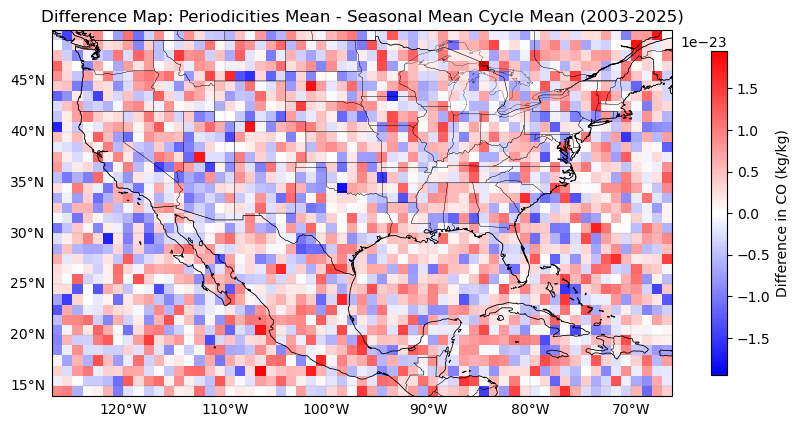

In [39]:
vmax = float(abs(diff_map).max())
plot_map(diff_map,
         "Difference Map: Periodicities Mean - Seasonal Mean Cycle Mean (2003-2025)",
         "Difference in CO (kg/kg)",
         cmap="bwr", vmin=-vmax, vmax=vmax)

## 12. Comparing the periodicities mean map and the seasonal mean cycle SD map

In [45]:
diff_map = seasonal_std_map - per_std_map

bias = float(diff_map.mean())
rmse = float((diff_map ** 2).mean() ** 0.5)
max_abs_diff = float(abs(diff_map).max())
corr = float(xr.corr(seasonal_std_map, per_std_map))

print("bias (seasonal - per) :", bias)
print("RMSE                  :", rmse)
print("max abs difference    :", max_abs_diff)
print("spatial correlation   :", corr)

bias (seasonal - per) : 3.275042432246042e-11
RMSE                  : 3.8142817838972965e-11
max abs difference    : 2.2620567917547254e-10
spatial correlation   : 0.9999511708990805


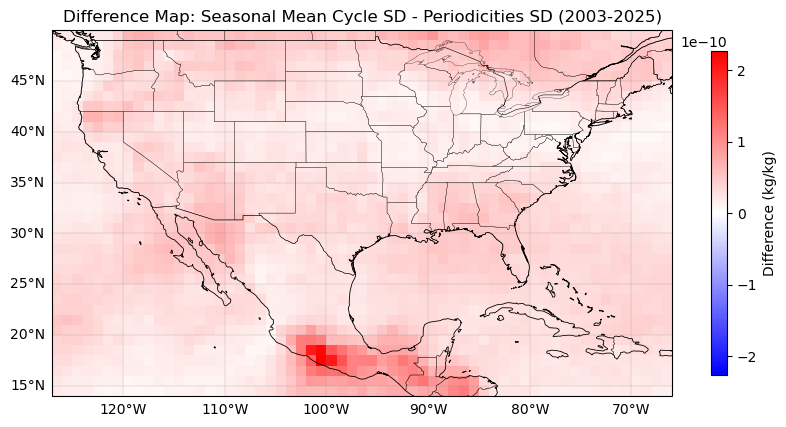

In [46]:
vmax = float(abs(diff_map).max())
plot_map(diff_map,
         "Difference Map: Seasonal Mean Cycle SD - Periodicities SD (2003-2025)",
         "Difference (kg/kg)",
         cmap="bwr", vmin=-vmax, vmax=vmax)